In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
df=pd.read_csv("data.csv")

In [3]:
df2=df.copy()

# Expoletory Data Analysis (EDA)

In [4]:
df2.head(3)

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0


In [5]:
df.tail(3)

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
7688,"2 BHK Flat for Rent in Malpani Vivanta, Balewa...",Balewadi,Pune,734.0,2,2,2,Unfurnished,48.0,35000.0
7689,"1 BHK Flat for Rent in Shalimar bagh, New Delhi",Shalimar bagh,New Delhi,400.0,1,1,0,Semi-Furnished,38.0,15000.0
7690,"2 BHK Flat for Rent in Govindpura, Dooravani N...",Govindpura,Bangalore,450.0,2,1,0,Unfurnished,22.0,10000.0


In [6]:
df2.shape

(7691, 10)

In [7]:
df2.columns

Index(['house_type', 'locality', 'city', 'area', 'beds', 'bathrooms',
       'balconies', 'furnishing', 'area_rate', 'rent'],
      dtype='str')

In [8]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 7691 entries, 0 to 7690
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   house_type  7691 non-null   str    
 1   locality    7691 non-null   str    
 2   city        7691 non-null   str    
 3   area        7691 non-null   float64
 4   beds        7691 non-null   int64  
 5   bathrooms   7691 non-null   int64  
 6   balconies   7691 non-null   int64  
 7   furnishing  7691 non-null   str    
 8   area_rate   7691 non-null   float64
 9   rent        7691 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 601.0 KB


In [9]:
df2.describe()

,area,beds,bathrooms,balconies,area_rate,rent
count,7691.000000,7691.000000,7691.000000,7691.000000,7691.000000,7.691000e+03
mean,1106.354180,2.208685,2.137043,0.817319,47.619989,5.479508e+04
std,1197.426843,0.993481,1.027677,1.243361,68.989657,9.742006e+04
min,2.000000,1.000000,0.000000,0.000000,2.000000,1.000000e+03
25%,600.000000,1.000000,1.000000,0.000000,21.000000,1.500000e+04
50%,900.000000,2.000000,2.000000,0.000000,31.000000,2.800000e+04
75%,1300.000000,3.000000,3.000000,2.000000,54.000000,5.700000e+04
max,70000.000000,10.000000,10.000000,10.000000,2586.000000,2.700000e+06


In [10]:
df2.isnull().sum()

house_type    0
locality      0
city          0
area          0
beds          0
bathrooms     0
balconies     0
furnishing    0
area_rate     0
rent          0
dtype: int64

In [11]:
df2.duplicated().sum()

np.int64(0)

# Distribution plot

<Axes: xlabel='rent', ylabel='Count'>

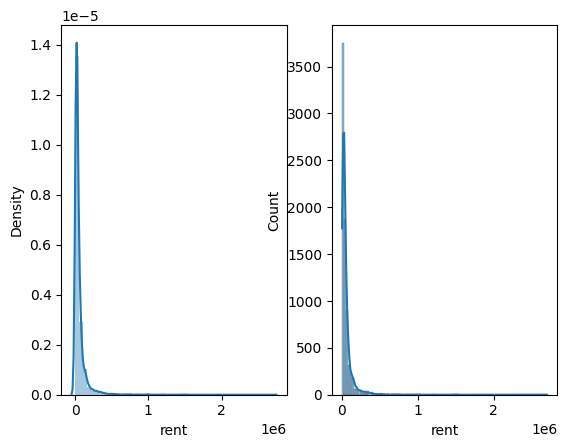

In [12]:
plt.subplot(1,2,1)
sns.distplot(df2["rent"],kde=True)
plt.subplot(1,2,2)
sns.histplot(df2["rent"],kde=True,bins=100)

<Axes: xlabel='rent'>

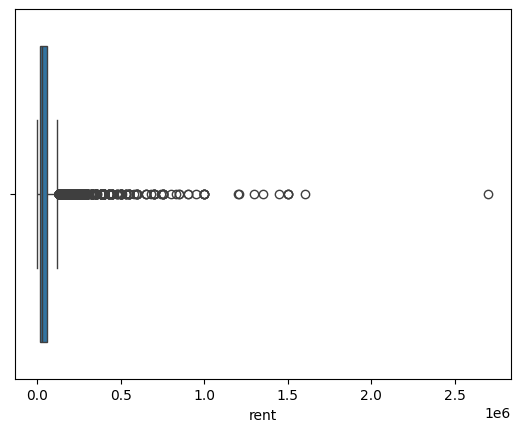

In [13]:
sns.boxplot(x=df2["rent"])

In [14]:
df2["rent"].skew()

np.float64(8.601656894334582)

In [15]:
df2.columns

Index(['house_type', 'locality', 'city', 'area', 'beds', 'bathrooms',
       'balconies', 'furnishing', 'area_rate', 'rent'],
      dtype='str')

In [16]:
df2_numerical=[ 'area', 'beds', 'bathrooms','balconies', 'area_rate']

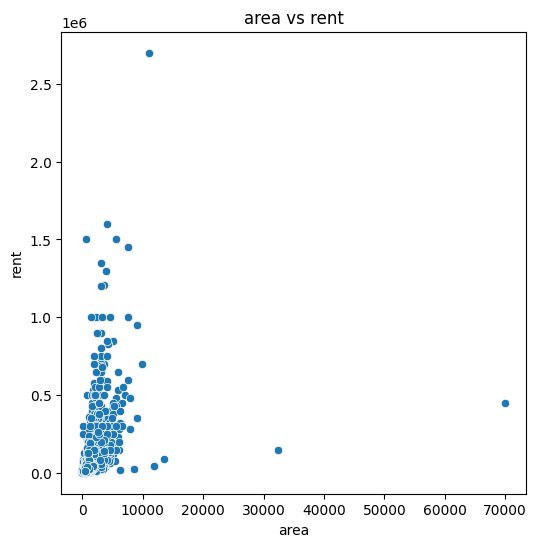

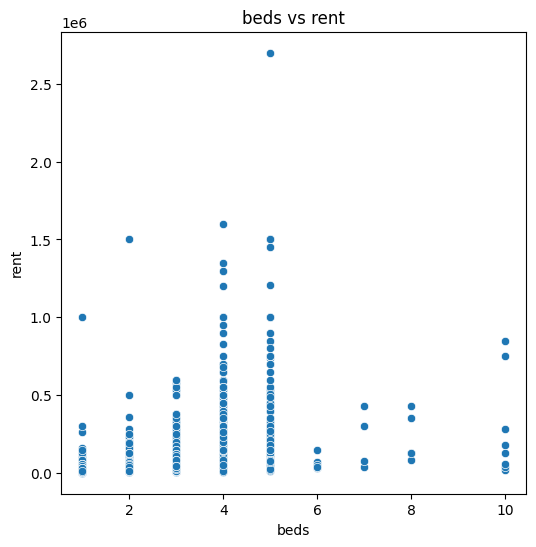

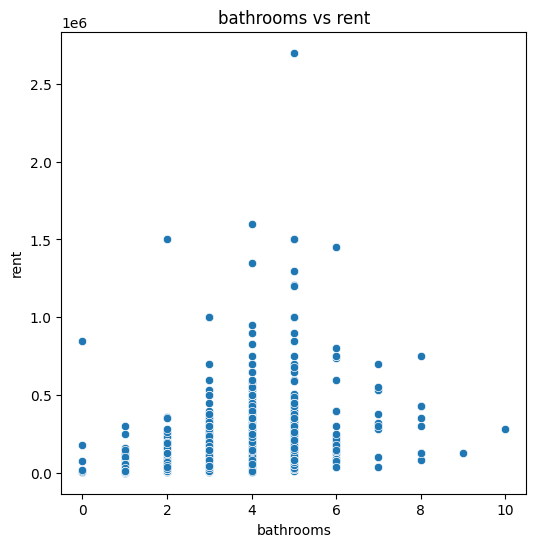

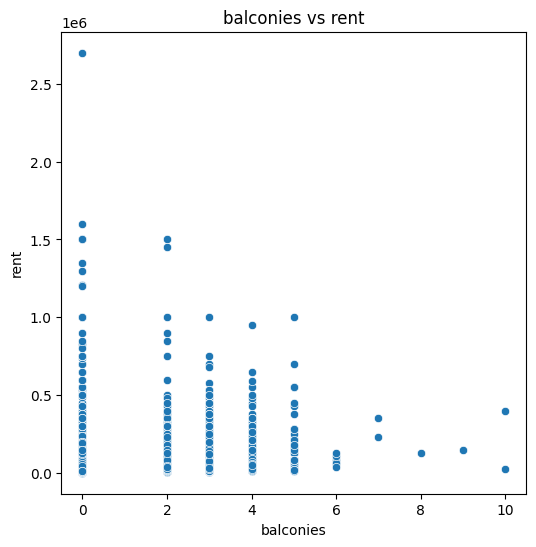

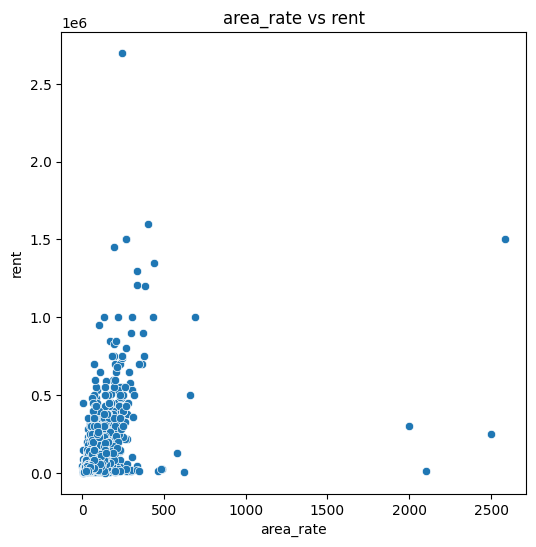

In [17]:
for i in df2_numerical:
    plt.figure(figsize=(6,6))
    sns.scatterplot(y=df2["rent"],x=df2[i])
    plt.title(f"{i} vs rent")

<Axes: >

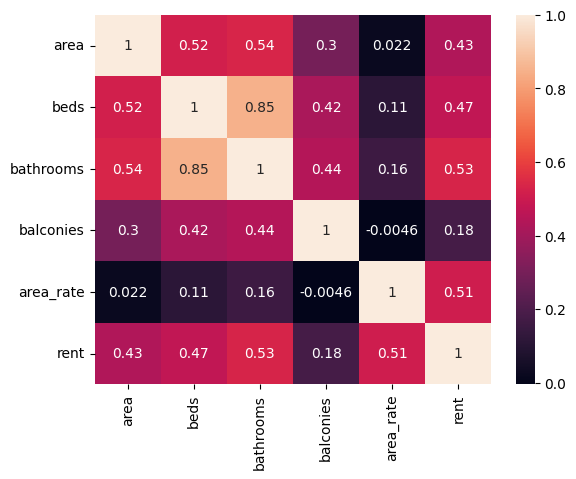

In [18]:
sns.heatmap(df2.corr(numeric_only=True),annot=True)

<Axes: xlabel='count', ylabel='city'>

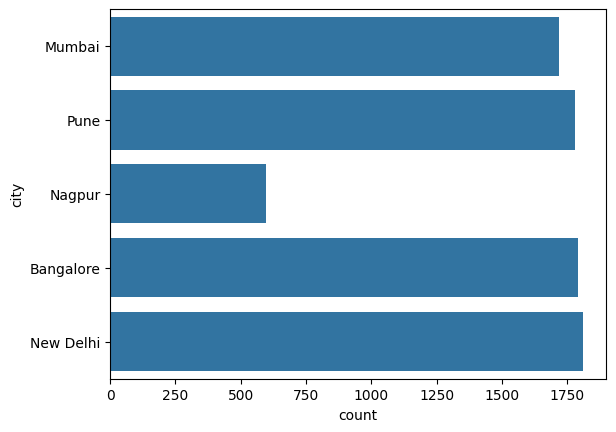

In [19]:
sns.countplot(df2["city"])

# Data Preprosessing and Cleaning

In [20]:
df2.isnull().sum()

house_type    0
locality      0
city          0
area          0
beds          0
bathrooms     0
balconies     0
furnishing    0
area_rate     0
rent          0
dtype: int64

In [21]:
numerical_columns=df2.select_dtypes(include=np.number).columns
categorical_columns=df2.select_dtypes(include="object").columns

In [22]:
numerical_columns

Index(['area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent'], dtype='str')

In [23]:
categorical_columns

Index(['house_type', 'locality', 'city', 'furnishing'], dtype='str')

# Encoding 

In [24]:
df2["house_type"].value_counts()

house_type
3 BHK Flat for Rent in Whitefield, Bangalore                     28
3 BHK Flat for Rent in Hebbal, Bangalore                         24
3 BHK Flat for Rent in Sarjapur Road, Bangalore                  24
3 BHK Flat for Rent in Oberoi Sky City, Borivali East, Mumbai    20
1 BHK Flat for Rent in Hadapsar, Pune                            19
                                                                 ..
1 BHK Flat for Rent in Baprola, New Delhi                         1
2 BHK Flat for Rent in Khar West, Mumbai                          1
1 BHK Flat for Rent in Link View, IC Colony, Mumbai               1
2 BHK Flat for Rent in Malpani Vivanta, Balewadi, Pune            1
2 BHK Flat for Rent in Govindpura, Dooravani Nagar, Bangalore     1
Name: count, Length: 5467, dtype: int64

In [25]:
df2=pd.get_dummies(df2,columns=["furnishing"])

# Label Encoding

In [26]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [27]:
categorical_Label_Encoder=['furnishing_Furnished',
       'furnishing_Semi-Furnished', 'furnishing_Unfurnished']
for i in categorical_Label_Encoder:
    df2[i]=le.fit_transform(df2[i])

In [28]:
df2.columns

Index(['house_type', 'locality', 'city', 'area', 'beds', 'bathrooms',
       'balconies', 'area_rate', 'rent', 'furnishing_Furnished',
       'furnishing_Semi-Furnished', 'furnishing_Unfurnished'],
      dtype='str')

In [29]:
df2["beds"].value_counts()

beds
2     3046
3     2035
1     1947
4      541
5       99
10       8
6        6
8        5
7        4
Name: count, dtype: int64

In [30]:
df2["city"].value_counts()

city
New Delhi    1808
Bangalore    1790
Pune         1779
Mumbai       1719
Nagpur        595
Name: count, dtype: int64

In [31]:
df2["city"]=le.fit_transform(df2["city"])

In [32]:
freq=df2["locality"].value_counts()
df2["locality"]=df2["locality"].map(freq)

In [33]:
df2["house_type"].value_counts()

house_type
3 BHK Flat for Rent in Whitefield, Bangalore                     28
3 BHK Flat for Rent in Hebbal, Bangalore                         24
3 BHK Flat for Rent in Sarjapur Road, Bangalore                  24
3 BHK Flat for Rent in Oberoi Sky City, Borivali East, Mumbai    20
1 BHK Flat for Rent in Hadapsar, Pune                            19
                                                                 ..
1 BHK Flat for Rent in Baprola, New Delhi                         1
2 BHK Flat for Rent in Khar West, Mumbai                          1
1 BHK Flat for Rent in Link View, IC Colony, Mumbai               1
2 BHK Flat for Rent in Malpani Vivanta, Balewadi, Pune            1
2 BHK Flat for Rent in Govindpura, Dooravani Nagar, Bangalore     1
Name: count, Length: 5467, dtype: int64

In [34]:
df2.drop("house_type",axis=1,inplace=True)

In [35]:
df2

,locality,city,area,beds,bathrooms,balconies,area_rate,rent,furnishing_Furnished,furnishing_Semi-Furnished,furnishing_Unfurnished
0,55,1,897.0,2,2,0,134.0,120000.0,0,1,0
1,47,1,490.0,1,1,0,82.0,40000.0,0,1,0
2,13,4,550.0,1,1,0,22.0,12000.0,0,0,1
3,4,2,1000.0,2,2,0,8.0,8000.0,0,0,1
4,44,1,595.0,1,1,0,25.0,15000.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
7686,34,3,1750.0,3,3,0,27.0,47000.0,1,0,0
7687,11,0,1050.0,2,2,2,27.0,28000.0,0,1,0
7688,23,4,734.0,2,2,2,48.0,35000.0,0,0,1
7689,11,3,400.0,1,1,0,38.0,15000.0,0,1,0


# Feature Selection

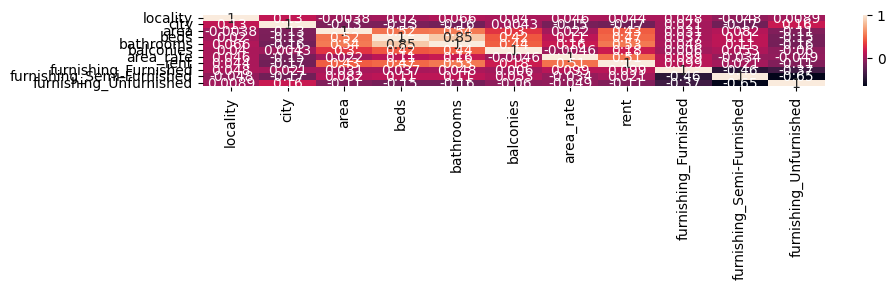

In [36]:
plt.figure(figsize=(10,3))
sns.heatmap(df2.corr(),annot=True)
plt.tight_layout()
plt.show()

# drop based on Feature Selection

In [37]:
df2=df2.drop([ 'locality','balconies',
        'furnishing_Furnished',
       'furnishing_Semi-Furnished', 'furnishing_Unfurnished'],axis=1)

In [38]:
df2

,city,area,beds,bathrooms,area_rate,rent
0,1,897.0,2,2,134.0,120000.0
1,1,490.0,1,1,82.0,40000.0
2,4,550.0,1,1,22.0,12000.0
3,2,1000.0,2,2,8.0,8000.0
4,1,595.0,1,1,25.0,15000.0
...,...,...,...,...,...,...
7686,3,1750.0,3,3,27.0,47000.0
7687,0,1050.0,2,2,27.0,28000.0
7688,4,734.0,2,2,48.0,35000.0
7689,3,400.0,1,1,38.0,15000.0


In [39]:
x=df2.drop("rent",axis=1)
y=df2["rent"]

# Start Your Ml Journey

In [40]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2
)

In [41]:
from sklearn.preprocessing import StandardScaler
Scaler=StandardScaler()
X_train_scaler=Scaler.fit_transform(x_train)
X_test_scaler=Scaler.transform(x_test)

# Starting to Create Model

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB

# Creating Object of Model

In [43]:
models={
    "Linear Regression":LinearRegression(),
    "KNN Model":KNeighborsRegressor(),
    "Decision Tree":DecisionTreeRegressor(),
}

# Cross validation Score

In [44]:
from sklearn.model_selection import cross_val_score

In [45]:
for name,model in models.items():
    scores=cross_val_score(model,X_train_scaler,y_train,cv=5,scoring="r2")
    print(name)
    print(scores.mean())
    print()

Linear Regression
0.4768696463165445

KNN Model
0.836841899509067

Decision Tree
0.9183409597608729



# Best Model

In [46]:
best_model=DecisionTreeRegressor()

In [47]:
best_model.fit(X_train_scaler,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [48]:
Y_predict=best_model.predict(X_test_scaler)

In [49]:
Y_predict

array([120000.,  20000.,  45000., ...,  35000.,   8000.,  12000.],
      shape=(1539,))

In [50]:
from sklearn.metrics import r2_score,accuracy_score,confusion_matrix,classification_report

In [51]:
r2_score(y_test,Y_predict)

0.9058444654048857

In [52]:
df2.columns


Index(['city', 'area', 'beds', 'bathrooms', 'area_rate', 'rent'], dtype='str')

In [55]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Load Data
df = pd.read_csv("data.csv")

# Features and Target
X = df[['city', 'area', 'beds', 'bathrooms', 'area_rate']]
y = df['rent']

# Categorical & Numerical Columns
cat_cols = ['city']
num_cols = ['area', 'beds', 'bathrooms', 'area_rate']

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('city', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train
pipeline.fit(X_train, y_train)

# Test
pred = pipeline.predict(X_test)

print("R2 Score :", r2_score(y_test, pred))

# Save Entire Pipeline
import joblib

joblib.dump(pipeline, "rent_pipeline.pkl", compress=9)
print("Pipeline Saved Successfully")

R2 Score : 0.9427478624083835
Pipeline Saved Successfully


In [56]:
import joblib
import pandas as pd

model = joblib.load("rent_pipeline.pkl")

sample = pd.DataFrame({
    "city": ["Mumbai"],
    "area": [1200],
    "beds": [3],
    "bathrooms": [2],
    "area_rate": [50]
})

prediction = model.predict(sample)

print("Predicted Rent:", prediction[0])

Predicted Rent: 60430.0
